In [19]:
import os
from dotenv import load_dotenv

import geopandas
import pandas as pd
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
import math
import matplotlib.colors as mcolors

import cartopy.crs as ccrs

# Load Data

In [22]:
load_dotenv(dotenv_path="/home/emily_zuetell/projects/poreallas/env_local")
#EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
EFFECTS_URI ="/home/emily_zuetell/projects/poreallas/scripts/data/projected_20250613.zarr"
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]

In [23]:
projected = xr.open_datatree(EFFECTS_URI, engine = 'zarr')
socioeconomics =  xr.open_zarr("/home/emily_zuetell/projects/poreallas/scripts/data/socioeconomics_local.zarr")

In [24]:
_polygons = (
    geopandas.read_parquet("/home/emily_zuetell/projects/poreallas/scripts/data/impact_region.parquet")
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)
_polygons_effect = _polygons.merge(
    projected["/forecast"]["effect"]
    .mean(dim="number").groupby("time.month")
        .mean()
    .to_dataframe()
    .reset_index(),
    on="region",
)
_polygons_socioecon = _polygons.merge(
    socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop']]
    .to_dataframe()
    .reset_index(),
    on="region",
)

In [25]:
_max_year = projected["/baseline"]["time"].max().dt.year.item()
# Subtracting 9 even though we want 10 year baseline because the time slice is an inclusive range.
_min_year = _max_year - 30
baseline_period = slice(str(_min_year), str(_max_year))

### Compute Impact

In [26]:
#Hotonly
_baseline = (
    projected["/baseline_hotonly"]["effect"]
    .sel(time=baseline_period)
    .groupby("time.month")
    .mean()
)
_forecast = (
    projected["/forecast_hotonly"]["effect"].mean(dim="number").groupby("time.month").mean()
)
impact = _forecast - _baseline
impact.name = "impact"
impact.attrs["long_name"] = "Temperature mortality impact"
impact.attrs["units"] = "Deaths per 100,000 people"
impact.attrs['hotonly'] = True

_polygons_impact_hotonly = _polygons.merge(
    impact.to_dataframe().reset_index(),
    on="region",
)
## Net
_baseline = (
    projected["/baseline"]["effect"]
    .sel(time=baseline_period)
    .groupby("time.month")
    .mean()
)
_forecast = (
    projected["/forecast"]["effect"].mean(dim="number").groupby("time.month").mean()
)
impact = _forecast - _baseline
impact.name = "impact"
impact.attrs["long_name"] = "Temperature mortality impact"
impact.attrs["units"] = "Deaths per 100,000 people"
impact.attrs['hotonly'] = False

_polygons_impact_net = _polygons.merge(
    impact.to_dataframe().reset_index(),
    on="region",
)

## Climate Data

In [27]:
ds_hindcast = xr.open_dataset('./data/s51_hcm_allmonths.nc')
da_hindcast = ds_hindcast['t2m'].assign_coords(forecast_reference_time=ds_hindcast.forecast_reference_time.dt.month).rename({'forecast_reference_time':'month'})

ds_era5_hcperiod = xr.open_dataset("./data/era5_monthly_1981_2016.nc")
da_era5 = ds_era5_hcperiod['t2m'].sel(valid_time = slice("1993-01-01", "2016-12-01")).groupby("valid_time.month").mean()

#regridder = xe.Regridder(da_era5, da_hindcast, "bilinear")
#da_era5_regridded = regridder(da_era5)
da_era5_regridded = da_era5.interp_like(da_hindcast, method="linear")

ds_forecast = xr.open_zarr("./data/tas_forecast.zarr")
ds_forecast = ds_forecast.swap_dims({'forecast_period': 'valid_time'})

era5_mortality_baseline = xr.open_zarr('/home/emily_zuetell/projects/poreallas/scripts/data/tas_ERA5.zarr')
era5_mortality_baseline = era5_mortality_baseline['tas'].sel(time = slice("1995-01-01", "2025-12-31")).groupby("time.month").mean()

In [28]:
### Impact Region - Avg Temps ###
era5_region_temp = pd.read_parquet("/home/emily_zuetell/projects/poreallas/scripts/data/era5_monthly_climatology_1995-2025.parquet")
forecast_region_temp = pd.read_parquet("/home/emily_zuetell/projects/poreallas/scripts/data/forecast_monthly_tas.parquet")
forecast_region_temp = forecast_region_temp.groupby([forecast_region_temp['region'], forecast_region_temp['time'].dt.month])['tas'].mean().reset_index().rename(columns={'time': 'month'})

df1 = forecast_region_temp
df2 = era5_region_temp
merged = df1.merge(df2, on=['region', 'month'], suffixes=('_forecast', '_era5'))
merged['tas_diff'] = merged['tas_forecast'] - merged['tas_era5']

merged = merged[['region','month','tas_diff']]
df_climate_IR_panel = _polygons.merge(merged.reset_index(), on="region").to_crs("ESRI:54030")
df_climate_IR_csv = merged.pivot(index='region', columns='month', values='tas_diff').rename(columns=lambda c: f'month {c} tas_diff').rename_axis(columns=None).reset_index()
#df_climate_IR_csv.to_csv('temp_region.csv')

In [29]:
## Population-Weighted Effects
def pop_weight_sum(col, time_col = 'month', rate = True, hotonly = False, age_weight = True):
    if hotonly:
        _polygons_impact = _polygons_impact_hotonly
    else:
        _polygons_impact = _polygons_impact_net

    if col =='impact':
        df = _polygons_impact.merge(_polygons_socioecon)
    elif col == 'effect':
        df = _polygons_effect.merge(_polygons_socioecon)
    elif col == 'baseline':
        df = _polygons_baseline.merge(_polygons_socioecon)
        col = 'effect'
        time_col = 'month'
    if age_weight:
        df['age_weighted_total'] = df[col] * np.select(
            [df['age_cohort'] == c for c in ['age0to4', 'age5to64', 'age65plus']],
            [df['pop0to4'], df['pop5to64'], df['pop65plus']]
        )/100000

        if rate:
            df['age_weighted_total'] = df['age_weighted_total']*100000/df['pop']
        else:
            df['age_weighted_total'] = df['age_weighted_total']
    else:
        df['age_weighted_total'] = df[df['age_cohort'] == 'age65plus'][col]

    
    regional_sum = df.groupby([time_col, 'region'])['age_weighted_total'].sum().reset_index()
    return regional_sum

# Impact Panels

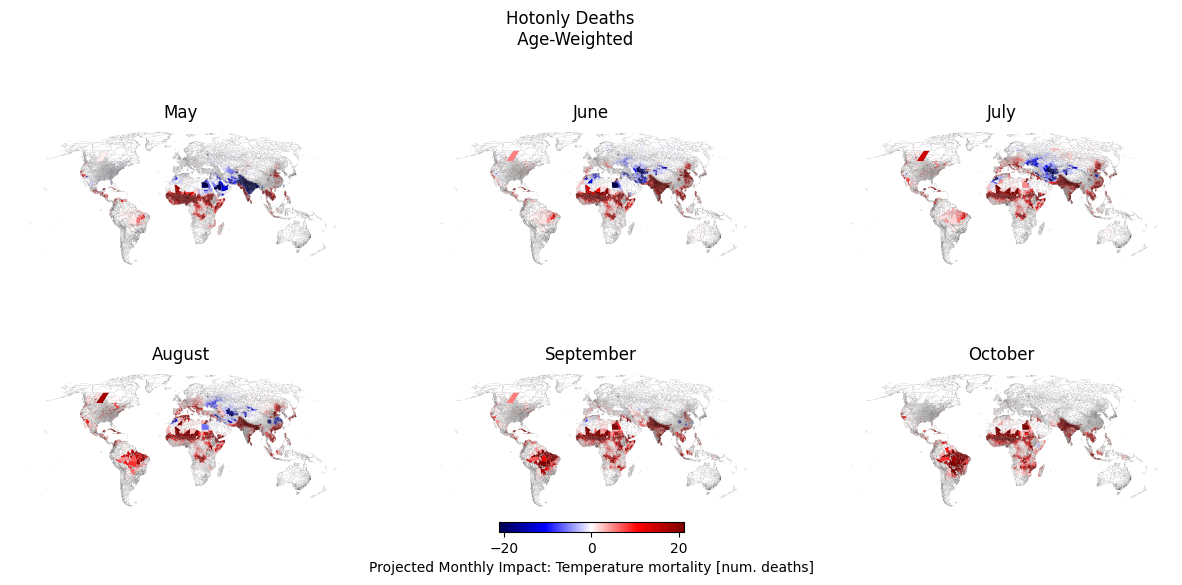

In [30]:
hotonly = True
rate = False
cumulative = False
use_log = False


regional_sum = pop_weight_sum(col='impact', rate=rate, hotonly = hotonly)

label01 = "Projected Cumulative Impact" if cumulative else "Projected Monthly Impact"
label = f"{label01}: {projected['/forecast']['effect'].attrs['long_name']} [{projected['/forecast']['effect'].attrs['units']}]" if rate else f"{label01}: {projected['/forecast']['effect'].attrs['long_name']} [num. deaths]"

if cumulative:
    _polygons_data = _polygons.merge(
        regional_sum.groupby('region')['age_weighted_total'].sum().reset_index(),
        on="region",
    )
    _plot_data = _polygons_data.to_crs("ESRI:54030")
    absmax = _plot_data['age_weighted_total'].abs().quantile(0.95)
    norm = mcolors.SymLogNorm(linthresh=1, vmin=-absmax, vmax=absmax)

    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    _plot_data.plot(column="age_weighted_total", legend=True, ax=ax, cmap="seismic", norm=norm,
        legend_kwds={"label": label, "orientation": "horizontal"})
    ax.set_axis_off()
    ax.set_title(f"Baseline: {_min_year}–{_max_year}")

else:
    months = sorted(regional_sum['month'].unique())
    ncols = 3
    nrows = math.ceil(len(months) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
    axes = axes.flatten()

    # Compute shared norm across all months
    _polygons_all = _polygons.merge(regional_sum.reset_index(), on="region").to_crs("ESRI:54030")
    absmax_impact = _polygons_all['age_weighted_total'].abs().quantile(0.95)
    if use_log:
        norm = mcolors.SymLogNorm(linthresh=1, vmin=-absmax_impact, vmax=absmax_impact)
    else:
        norm = mcolors.TwoSlopeNorm(vmin=-absmax_impact, vcenter=0, vmax=absmax_impact)

    for i, month in enumerate(months):
        _polygons_data = _polygons.merge(
            regional_sum[regional_sum['month'] == month].reset_index(),
            on="region",
        )
        _plot_data = _polygons_data.to_crs("ESRI:54030")

        _plot_data.plot(column="age_weighted_total", legend=False, ax=axes[i],
            cmap="seismic", norm=norm, edgecolor = 'black',
    linewidth=0.03,)
        axes[i].set_axis_off()
        axes[i].set_title(pd.Timestamp(2026, month, 1).strftime('%B'))

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Shared colorbar
    sm = plt.cm.ScalarMappable(cmap="seismic", norm=norm)
    fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.02, pad=0.02, label=label)

    label = 'Death Rate' if rate else "Deaths"
    label_h = 'Hotonly' if hotonly else 'Net'
    fig.suptitle(f"{label_h} {label} \n Age-Weighted")
    label_f = 'death_rate' if rate else "deaths"

    fig.savefig(f'{label_h}_{label_f}_agewtd.png', dpi=600, bbox_inches="tight")

### Statistics

In [31]:
hotonly = False
rate = False
cumulative = False
use_log = False


regional_sum = pop_weight_sum(col='impact', rate=rate, hotonly = hotonly)
polygons_country = _polygons[_polygons['ISO']=='IND']
#polygons_country = _polygons.loc['IND.16.212.746']

_polygons_all = polygons_country.merge(regional_sum.reset_index(), on="region").to_crs("ESRI:54030")
df = _polygons_all[['region', 'month', 'age_weighted_total']].rename(columns={'age_weighted_total': 'deaths'})
df = df.pivot(index='region', columns='month', values='deaths').rename(columns=lambda c: f'month {c} deaths').rename_axis(columns=None).reset_index()
month_cols = [c for c in df.columns if c.startswith('month')]

df['deaths_5mo'] = df[month_cols[1:]].sum(axis=1)
df['deaths_6mo'] = df[month_cols].sum(axis=1)

In [187]:
df.to_csv('net_deathrates_agewtd_IND.csv')

In [193]:
df_pop = df.merge(_polygons_socioecon)

In [199]:
df.sum()['deaths_5mo']/(df_pop['pop'].sum()/100000)

np.float64(12.956916770584503)

In [194]:
df.sum()

region             IND.1.1.1IND.1.2.2IND.10.121.371IND.11.122.372...
month 5 deaths                                         -108759.33736
month 6 deaths                                          62936.939502
month 7 deaths                                          39900.352022
month 8 deaths                                          34385.039337
month 9 deaths                                          37000.459809
month 10 deaths                                         14524.338139
deaths_5mo                                             188747.128808
deaths_6mo                                              79987.791448
dtype: object

In [67]:
df.to_csv("net_deathrate_agewtd.csv")

# Climate Panels

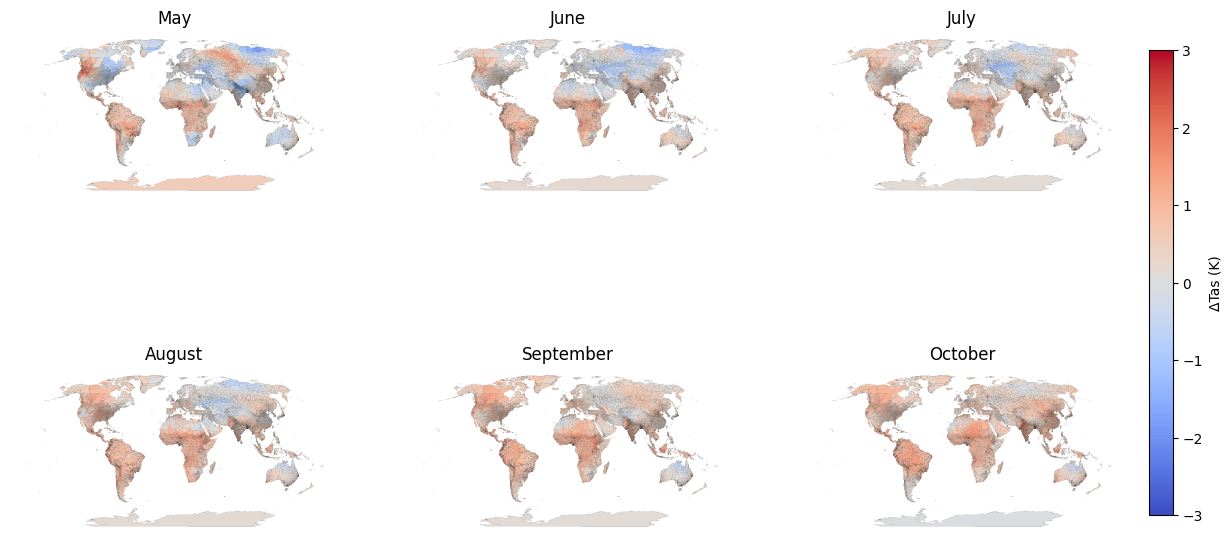

In [32]:


df = df_climate_IR_panel

months = sorted(df['month'].unique())
ncols = 3
nrows = math.ceil(len(months) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, month in enumerate(months):
    ax = axes[i]
    month_data = df[df['month'] == month]
    month_data.plot(
        column="tas_diff",
        legend=False,
        edgecolor='black',
        cmap="coolwarm",
        linewidth=0.03,
        vmin=-5,
        vmax=5,
        ax=ax,
    )
    ax.set_title(pd.Timestamp(2026, month, 1).strftime('%B'))
    ax.set_axis_off()

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=-3, vmax=3))
fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, label="ΔTas (K)")

fig.savefig('temp_region.png', dpi=150, bbox_inches='tight')

Text(0.5, 0, 'Tas Anomaly [C]')

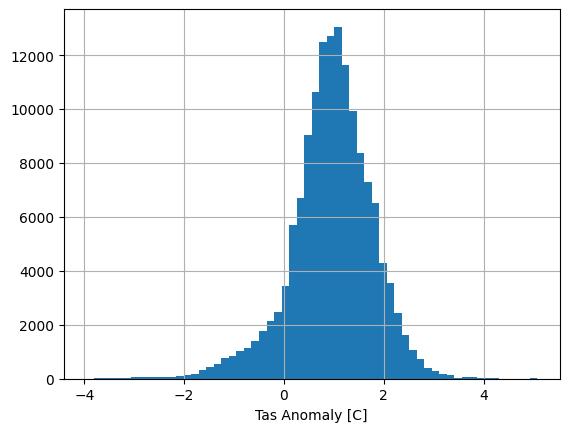

In [33]:
df['tas_diff'].hist(bins=60)
plt.xlabel('Tas Anomaly [C]')

# Paired Temp Impact

/tmp/ipykernel_76333/3315207529.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.95])


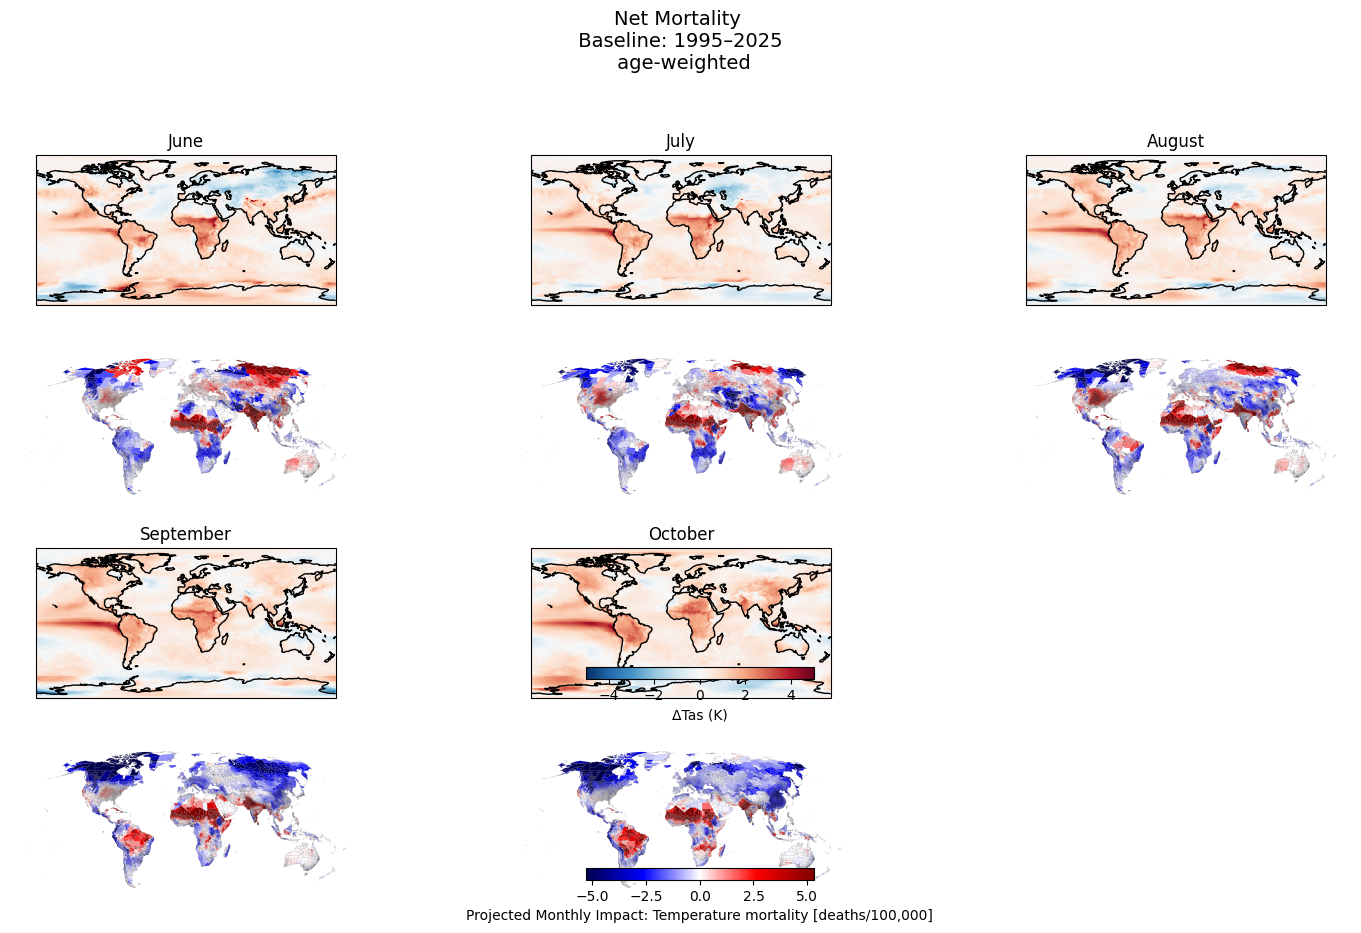

In [34]:
rate = True
use_log = False
age_weight = True

regional_sum = pop_weight_sum(col='impact', rate=rate, age_weight = age_weight)

months = sorted(regional_sum['month'].unique())[1:]  # drop first and last
base_month = months[0]
lead_by_month = {month: (month - base_month + 1) for month in months}

ncols = 3
n_months = len(months)
n_pairs = math.ceil(n_months / ncols)
total_rows = n_pairs * 2

fig = plt.figure(figsize=(5 * ncols, 5 * n_pairs))

top_axes = []
bot_axes = []
for i, month in enumerate(months):
    pair_row = i // ncols
    col = i % ncols
    top_row = pair_row * 2
    bot_row = pair_row * 2 + 1

    ax_top = fig.add_subplot(total_rows, ncols, top_row * ncols + col + 1, projection=ccrs.PlateCarree())
    ax_bot = fig.add_subplot(total_rows, ncols, bot_row * ncols + col + 1)
    top_axes.append(ax_top)
    bot_axes.append(ax_bot)

# --- Precompute temperature bias adjustments ---
bias_adj_all = []
for month in months:
    lead = lead_by_month[month]
    bias_adjustment = (
        da_hindcast.sel(month=(month - lead + 1), forecastMonth=lead)
        - da_era5_regridded.sel(month=month)
    )
    bias_adj_fc = (
        ds_forecast.sel(valid_time=ds_forecast.valid_time.dt.month == month)['tas']
        .mean(dim=['number', 'valid_time'])
        .squeeze()
        - era5_mortality_baseline.sel(month=month)
        - bias_adjustment
    )
    bias_adj_all.append(bias_adj_fc)

# --- Shared impact norm ---

_polygons_all = _polygons.merge(regional_sum.reset_index(), on="region").to_crs("ESRI:54030")
absmax_impact = _polygons_all['age_weighted_total'].abs().quantile(0.95)
if use_log:
    norm_impact = mcolors.SymLogNorm(linthresh=1, vmin=-absmax_impact, vmax=absmax_impact)
else:
    norm_impact = mcolors.TwoSlopeNorm(vmin=-absmax_impact, vcenter=0, vmax=absmax_impact)

# --- Plot ---
for i, month in enumerate(months):
    ax_top = top_axes[i]
    ax_bot = bot_axes[i]
    month_label = pd.Timestamp(2026, month, 1).strftime('%B')

    # Top: temperature
    im_temp = bias_adj_all[i].plot(
        ax=ax_top,
        transform=ccrs.PlateCarree(),
        vmin=-5, vmax=5,
        cmap='RdBu_r',
        add_colorbar=False,
    )
    ax_top.set_title(month_label)
    ax_top.coastlines()

    # Bottom: impact
    _polygons_data = _polygons.merge(
        regional_sum[regional_sum['month'] == month].reset_index(),
        on="region",
    )
    _plot_data = _polygons_data.to_crs("ESRI:54030")
    _plot_data.plot(
        column="age_weighted_total",
        legend=False,
        ax=ax_bot,
        cmap="seismic",
        norm=norm_impact,
        edgecolor='black',
        linewidth=0.03,
    )
    ax_bot.set_axis_off()

# --- Colorbars ---
sm_temp = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-5, vmax=5))
fig.colorbar(sm_temp, ax=top_axes, orientation="horizontal", fraction=0.02, pad=0.02, label="ΔTas (K)")

sm_impact = plt.cm.ScalarMappable(cmap="seismic", norm=norm_impact)

label01 = "Projected Monthly Impact"
units = "[deaths/100,000]" if rate else "[deaths]" 
label = f"{label01}: {projected['/forecast']['effect'].attrs['long_name']} [deaths/100,000]"
fig.colorbar(sm_impact, ax=bot_axes, orientation="horizontal", fraction=0.02, pad=0.02, label=label)

ag_label = "age-weighted" if age_weight else "Age Cohort: 65+"
fig.suptitle(f"Net Mortality \n Baseline: {_min_year}–{_max_year} \n {ag_label}", fontsize=14)



fig.savefig("monthly_hotonly_rates_1995_2025bl.png", dpi=600, bbox_inches="tight")
plt.tight_layout(rect=[0, 0.08, 1, 0.95])

In [16]:
import hvplot.pandas

month = 8
regional_sum = pop_weight_sum(col='impact', rate=rate)

_polygons_data = _polygons.merge(
    regional_sum[regional_sum['time'].dt.month == month].reset_index(),
    on="region",
).to_crs("EPSG:4326")

plot = _polygons_data.hvplot(
    geo=True,
    tiles="CartoLight",
    c="age_weighted_total",
    cmap="seismic",
    hover_cols=["region", "age_weighted_total"],
    clabel="Impact (deaths)",
    title=pd.Timestamp(2026, month, 1).strftime('%B'),
    alpha=0.6,
    line_color="black",
    line_width=0.5,
    width=900,
    height=500,
)

import hvplot
hvplot.save(plot, "impact_regions_interactive.html")

# Impact Region Diagnostics

In [36]:
era5_daily = xr.open_zarr('/home/emily_zuetell/projects/poreallas/scripts/data/tas_ERA5.zarr')
betas_mmt = xr.open_zarr("/home/emily_zuetell/projects/poreallas/scripts/data/beta_mmt.zarr")

In [49]:
from scipy.interpolate import interp1d

# Build interpolator for response curve
response_interp = interp1d(
    da_temp_bins.coords['tas_bin'].values,
    da_temp_bins.values,
    bounds_error=False, fill_value=0
)

response_interp = interp1d(
    da_temp_bins.coords['tas_bin'].values,
    da_temp_bins.values,
    bounds_error=False, fill_value=0
)

# For each distribution, compute weighted CDF
def weighted_cdf(data, n_bins=50):
    counts, edges = np.histogram(data, bins=n_bins, density=True)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    response_weights = response_interp(bin_centers)
    weighted = counts * response_weights
    cdf = np.cumsum(weighted) * np.diff(edges)  # normalize by bin width
    return bin_centers, cdf

def plot_hist_mmt(region, ax, month=None):
    hist_forecast = xr.open_zarr("histogram_forecast_tas.zarr")
    hist_hist = xr.open_zarr("histogram_hist_tas.zarr")
    betas_mmt = xr.open_zarr("/home/emily_zuetell/projects/poreallas/scripts/beta_mmt.zarr")

    hist_forecast = hist_forecast.sel(region=region)
    hist_hist = hist_hist.sel(region=region)

    combined1 = hist_forecast["histogram_tas"].isel(forecast_reference_time=0).sum("number").groupby("time.month").sum("time")
    combined2 = hist_hist["histogram_tas"].groupby("time.month").sum("time")

    def normalize(da):
        return (da - da.min()) / (da.max() - da.min())

    (normalize(combined1) - normalize(combined2)).plot(x="month", y="tas_bin", cmap="RdBu", xlim=(6,10), ylim=(0, 40), ax=ax, add_colorbar=False)

    ref_vals_old = float(betas_mmt['mmt'].sel(region=region, age_cohort='age65plus').values)
    ref_vals_young = float(betas_mmt['mmt'].sel(region=region, age_cohort='age0to4').values)
    ref_vals_mid = float(betas_mmt['mmt'].sel(region=region, age_cohort='age5to64').values)

    ax.axhline(y=ref_vals_old, color="black", linestyle="--", label='65plus')
    ax.axhline(y=ref_vals_young, color="orange", linestyle="--", label='0-4')
    ax.axhline(y=ref_vals_mid, color="green", linestyle="--", label='5-64')
    ax.legend(fontsize=7)

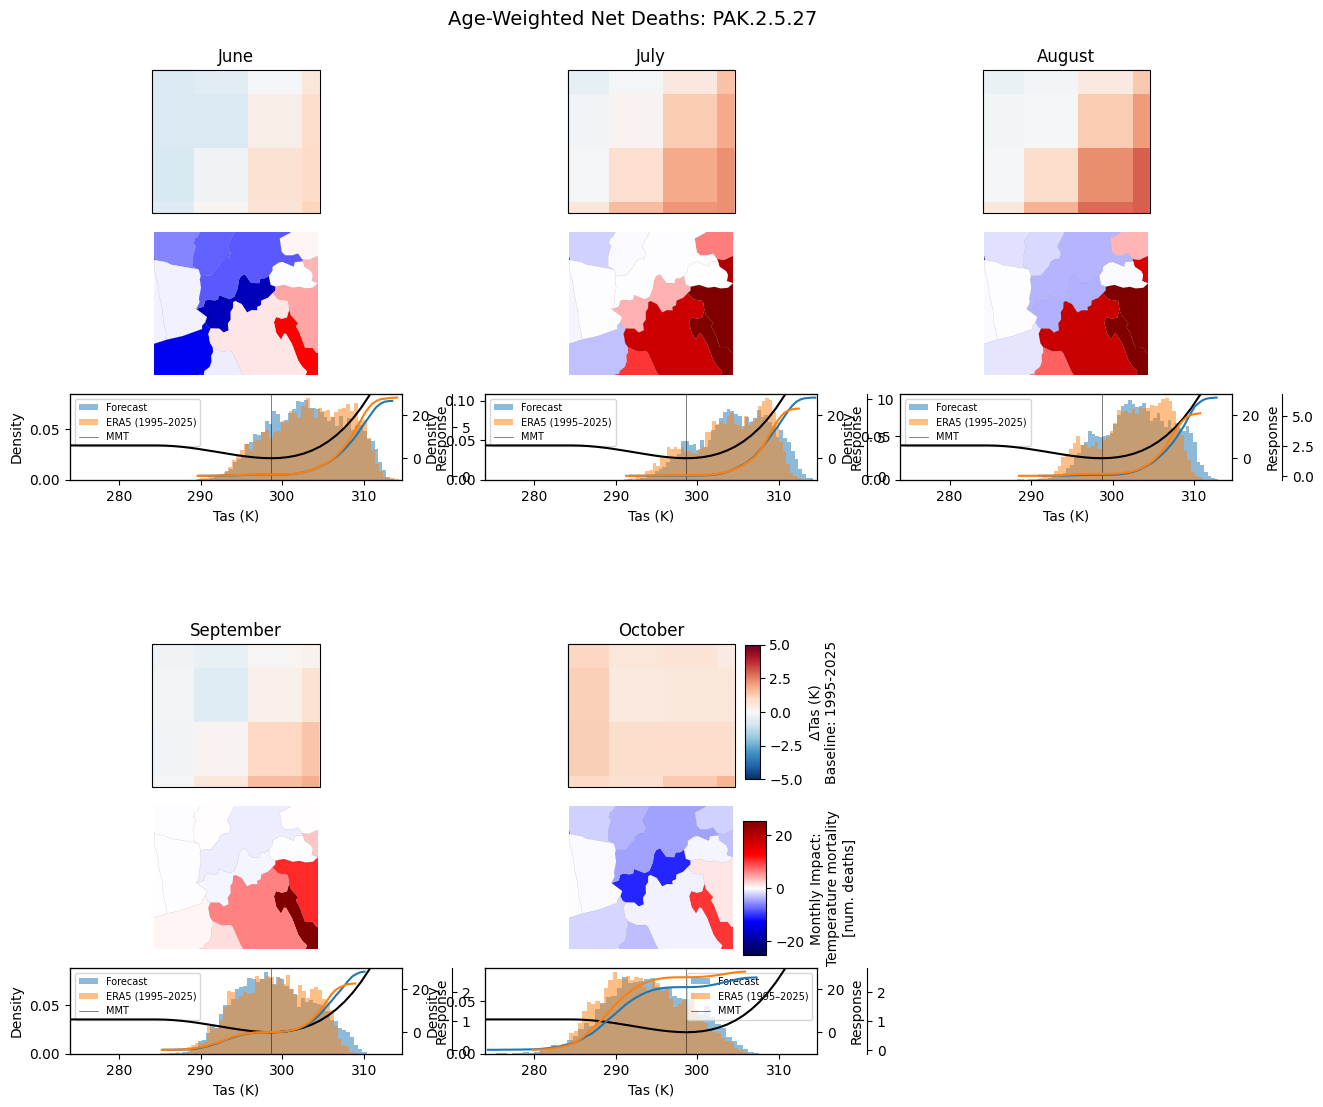

In [50]:
import cartopy.crs as ccrs

rate = False
hotonly = False
age_weight = True
use_log = False
density_hist = True
regional_sum = pop_weight_sum(col='impact', rate=rate, hotonly = hotonly, age_weight=age_weight)

region_filter = "PAK.2.5.27"
#region_filter = "IND.16.203.735"
#region_filter = "BRA.7.804.1862"
#region_filter = "IND.29.439.1743"
#region_filter = "CHN.11.109.767"  # set to None for global
#region_filter = "COD.3.15.51" 
#region_filter = "THA.76.909.5787"
#region_filter = "HRV.R4acd3465906d6fba"
#region_filter = "EGY.8"
#region_filter = 'BRA.9.R7ae8d9b7a4e0454f'
#region_filter = 'ZMB.9.67'

months = sorted(regional_sum['month'].unique())[1:]
base_month = months[0]
lead_by_month = {month: (month - base_month + 1) for month in months}

ncols = 3
n_months = len(months)
n_pairs = math.ceil(n_months / ncols)
total_rows = n_pairs * 3

# --- Region bbox ---
if region_filter:
    _country = _polygons[_polygons.index == region_filter].to_crs("EPSG:4326")
    minx, miny, maxx, maxy = _country.total_bounds
    bbox_pad = 1
    _country_proj = _country.to_crs("ESRI:54030")
    bminx, bminy, bmaxx, bmaxy = _country_proj.total_bounds
    pad_proj = 50000

fig = plt.figure(figsize=(5 * ncols, 6 * n_pairs))

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

gs = GridSpec(n_pairs, 1, figure=fig, hspace=0.4)

top_axes = []
bot_axes = []
hist_axes = []

for pair_row in range(n_pairs):
    inner_gs = GridSpecFromSubplotSpec(3, ncols, subplot_spec=gs[pair_row],
                                       hspace=0.15, wspace=0.25,
                                       height_ratios=[2, 2, 1.2])
    for col in range(ncols):
        i = pair_row * ncols + col
        if i >= n_months:
            break
        ax_top = fig.add_subplot(inner_gs[0, col], projection=ccrs.PlateCarree())
        ax_bot = fig.add_subplot(inner_gs[1, col])
        ax_hist = fig.add_subplot(inner_gs[2, col])
        top_axes.append(ax_top)
        bot_axes.append(ax_bot)
        hist_axes.append(ax_hist)

# --- Precompute temperature bias adjustments ---
bias_adj_all = []
bias_adj_iso_all = []
for month in months:
    lead = lead_by_month[month]
    bias_adjustment = (
        da_hindcast.sel(month=(month - lead + 1), forecastMonth=lead)
        - da_era5_regridded.sel(month=month)
    )
    bias_adj_fc = (
        ds_forecast.sel(valid_time=ds_forecast.valid_time.dt.month == month)['tas']
        .mean(dim=['number', 'valid_time'])
        .squeeze()
        - era5_mortality_baseline.sel(month=month)
        - bias_adjustment
    )
    bias_adj_all.append(bias_adj_fc)

    if region_filter:
        def roll_lon(da):
            return da.assign_coords(
                longitude=((da.longitude + 180) % 360 - 180)
            ).sortby('longitude')

        bias_adj_fc_iso = (
            roll_lon(ds_forecast.sel(valid_time=ds_forecast.valid_time.dt.month == month)['tas'])
            .squeeze()
            - roll_lon(bias_adjustment)
        ).sel(
            latitude=slice(maxy + bbox_pad, miny - bbox_pad),
            longitude=slice(minx - bbox_pad, maxx + bbox_pad),
        )

        bias_adj_iso_all.append(bias_adj_fc_iso)

# --- Shared impact norm ---

_polygons_all = _polygons.merge(regional_sum.reset_index(), on="region").to_crs("ESRI:54030")
absmax_impact = _polygons_all['age_weighted_total'].abs().quantile(0.95)
if use_log:
    norm_impact = mcolors.SymLogNorm(linthresh=1, vmin=-absmax_impact, vmax=absmax_impact)
else:
    norm_impact = mcolors.TwoSlopeNorm(vmin=-absmax_impact, vcenter=0, vmax=absmax_impact)

era5_rolled = era5_daily.assign_coords(
    longitude=((era5_daily.longitude + 180) % 360 - 180)
).sortby('longitude')

era5_local = era5_rolled.sel(
    latitude=slice(maxy + bbox_pad, miny - bbox_pad),
    longitude=slice(minx - bbox_pad, maxx + bbox_pad),
)
era5_local = (
    era5_local['tas']
    .sel(time=slice("1995-01-01", "2025-12-31"))
    .isel(time=era5_local.time.dt.month.isin(months))
)
xmin = min(era5_local.values.flatten().min(), min(b.values.flatten().min() for b in bias_adj_iso_all))
xmax = max(era5_local.values.flatten().max(), max(b.values.flatten().max() for b in bias_adj_iso_all))

# --- Plot ---
for i, month in enumerate(months):
    ax_top = top_axes[i]
    ax_bot = bot_axes[i]
    ax_hist = hist_axes[i]
    month_label = pd.Timestamp(2026, month, 1).strftime('%B')

    # Top: temperature
    im_temp = bias_adj_all[i].plot(
        ax=ax_top,
        transform=ccrs.PlateCarree(),
        vmin=-5, vmax=5,
        cmap='RdBu_r',
        add_colorbar=False,
    )
    ax_top.set_title(month_label)
    ax_top.coastlines()
    if region_filter:
        ax_top.set_extent(
            [minx - bbox_pad, maxx + bbox_pad, miny - bbox_pad, maxy + bbox_pad],
            crs=ccrs.PlateCarree()
        )

    # Middle: impact
    _polygons_data = _polygons.merge(
        regional_sum[regional_sum['month'] == month].reset_index(),
        on="region",
    )
    _plot_data = _polygons_data.to_crs("ESRI:54030")
    _plot_data.plot(
        column="age_weighted_total",
        legend=False,
        ax=ax_bot,
        cmap="seismic",
        norm=norm_impact,
        edgecolor='black',
        linewidth=0.03,
    )
    ax_bot.set_axis_off()
    if region_filter:
        ax_bot.set_xlim(bminx - pad_proj, bmaxx + pad_proj)
        ax_bot.set_ylim(bminy - pad_proj, bmaxy + pad_proj)

    # Bottom: histogram
    if region_filter:
        era5_local_month = era5_local.sel(time=era5_local.time.dt.month == month)


        ref_vals = betas_mmt['mmt'].sel(region=region_filter).sel(age_cohort='age65plus') + 273.15
        betas = betas_mmt['beta_hotonly'] if hotonly else betas_mmt['beta']
        da_temp_bins = betas.sel(region=region_filter).sel(age_cohort='age65plus')
        da_temp_bins['tas_bin'] = da_temp_bins['tas_bin'] + 273.15

        ax_hist.hist(bias_adj_iso_all[i].values.flatten(), bins=50, alpha=0.5, label="Forecast", density=density_hist)
        ax_hist.hist(era5_local_month.values.flatten(), bins=50, alpha=0.5, label="ERA5 (1995–2025)", density=density_hist)
        ax_hist.axvline(ref_vals.values, color='black', linewidth=0.5, alpha=0.7, label="MMT")

        ax_hist2 = ax_hist.twinx()
        ax_hist2.plot(da_temp_bins.coords['tas_bin'], da_temp_bins.values, color='black', linewidth=1.5, label="Response curve")
        ax_hist2.set_ylabel("Response")
        ax_hist2.set_ylim(-10, 30)

        ## Response CDFs
        era5_centers, era5_cdf = weighted_cdf(era5_local_month.values.flatten())
        fc_centers, fc_cdf = weighted_cdf(bias_adj_iso_all[i].values.flatten())

        ax3 = ax_hist.twinx()
        ax3.spines["right"].set_position(("axes", 1.15))

        ax3.plot(fc_centers, fc_cdf, label="Forecast weighted CDF")
        ax3.plot(era5_centers, era5_cdf, label="ERA5 weighted CDF")


        ax_hist.legend(fontsize=7)
        ax_hist.set_xlabel("Tas (K)")
        ax_hist.set_ylabel("Density")
        ax_hist.set_xlim(xmin, xmax)
        ax_hist2.set_xlim(xmin, xmax)
    else:
        ax_hist.set_visible(False)

# --- Colorbars ---
ax_oct_top = top_axes[-1]
ax_oct_bot = bot_axes[-1]

fig.canvas.draw()

pos_top = ax_oct_top.get_position()
cax_temp = fig.add_axes([pos_top.x1 + 0.01, pos_top.y0+0.02, 0.01, pos_top.height])
sm_temp = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-5, vmax=5))
fig.colorbar(sm_temp, cax=cax_temp, label="ΔTas (K)\nBaseline: 1995-2025")

pos_bot = ax_oct_bot.get_position()
cax_impact = fig.add_axes([pos_bot.x1 + 0.01, pos_bot.y0, 0.015, pos_bot.height])
sm_impact = plt.cm.ScalarMappable(cmap="seismic", norm=norm_impact)
label01 = "Monthly Impact"
units = "[deaths/100k]" if rate else "[num. deaths]"
label = f"{label01}:\n{projected['/forecast']['effect'].attrs['long_name']}\n{units}"
fig.colorbar(sm_impact, cax=cax_impact, label=label)


fig.subplots_adjust(top=0.93)

title_region = f" {region_filter}" if region_filter else ""
ag_label = "Age-Weighted" if age_weight else "Age Cohort: 65+"
label = 'Death Rate' if rate else "Deaths"
label_h = 'Hotonly' if hotonly else 'Net'

fig.suptitle(f"{ag_label} {label_h} {label}:{title_region}", fontsize=14)


label_f = 'death_rate' if rate else "deaths"

fig.savefig(f'{label_h}_{label_f}_agewtd{f'_{region_filter}' if region_filter else ''}.png', dpi=600, bbox_inches="tight")

(273.9574279785156, 314.7076721191406)

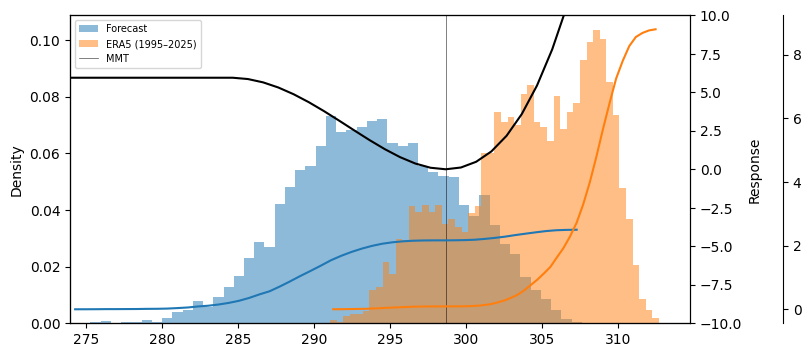

In [48]:
import numpy as np
from scipy.interpolate import interp1d

# Build interpolator for response curve
response_interp = interp1d(
    da_temp_bins.coords['tas_bin'].values,
    da_temp_bins.values,
    bounds_error=False, fill_value=0
)

# For each distribution, compute weighted CDF
def weighted_cdf(data, n_bins=50):
    counts, edges = np.histogram(data, bins=n_bins, density=True)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    response_weights = response_interp(bin_centers)
    weighted = counts * response_weights
    cdf = np.cumsum(weighted) * np.diff(edges)  # normalize by bin width
    return bin_centers, cdf

era5_centers, era5_cdf = weighted_cdf(era5_local_month.values.flatten())
fc_centers, fc_cdf = weighted_cdf(bias_adj_iso_all[i].values.flatten())

fig, ax_top = plt.subplots(1, 1, figsize=(8, 4), sharex=True)

# Original histogram + response curve
ax_top.hist(bias_adj_iso_all[i].values.flatten(), bins=50, alpha=0.5, label="Forecast", density=True)
ax_top.hist(era5_local_month.values.flatten(), bins=50, alpha=0.5, label="ERA5 (1995–2025)", density=True)
ax_top.axvline(ref_vals.values, color='black', linewidth=0.5, alpha=0.7, label="MMT")
ax2 = ax_top.twinx()
ax2.plot(da_temp_bins.coords['tas_bin'], da_temp_bins.values, color='black', linewidth=1.5, label="Response curve")
ax2.set_ylim(-10, 10)
ax2.set_ylabel("Response")
ax_top.legend(fontsize=7)
ax_top.set_ylabel("Density")

ax3 = ax_top.twinx()
ax3.spines["right"].set_position(("axes", 1.15))

ax3.plot(fc_centers, fc_cdf, label="Forecast weighted CDF")
ax3.plot(era5_centers, era5_cdf, label="ERA5 weighted CDF")


ax_top.set_xlim(xmin, xmax)

In [138]:
print(f"era5_local size: {era5_local.size}, shape: {dict(era5_local.sizes)}")
print(f"bias_adj_iso size: {bias_adj_iso_all[i].size}, shape: {dict(bias_adj_iso_all[i].sizes)}")

era5_local size: 52080, shape: {'time': 930, 'latitude': 8, 'longitude': 7}
bias_adj_iso size: 0, shape: {'number': 51, 'valid_time': 30, 'latitude': 8, 'longitude': 0}


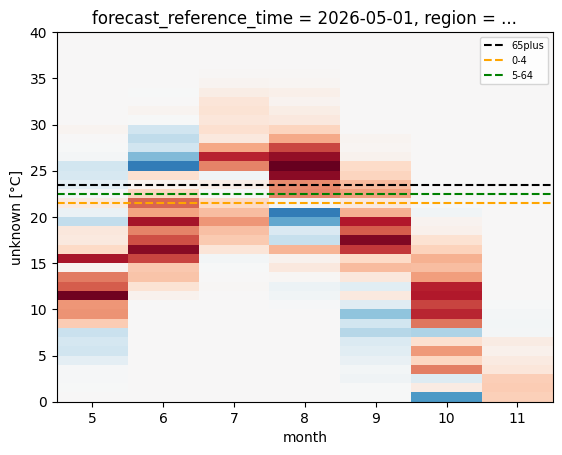

In [90]:
fig, ax = plt.subplots()
plot_hist_mmt("CHN.11.109.767", ax = ax)

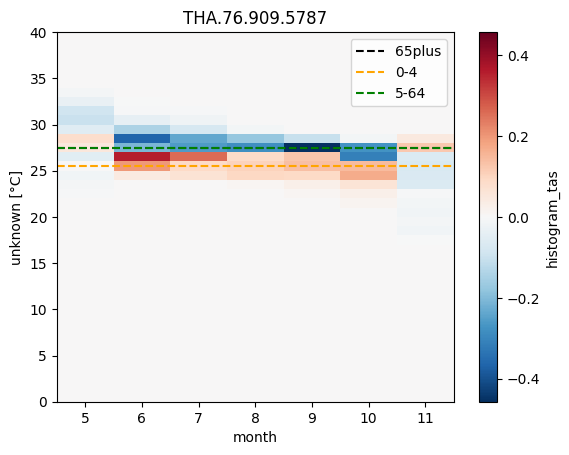

In [85]:
plot_hist_mmt("THA.76.909.5787")

# Computing MMT/Response Function

In [204]:
mmt_df = betas_mmt['mmt'].sel(age_cohort = 'age65plus').to_dataframe()
mmt_df = _polygons.merge(mmt_df.reset_index(), on="region").to_crs("ESRI:54030")

In [223]:
mmt_df[['region', 'mmt']].to_csv('region_mmt.csv')

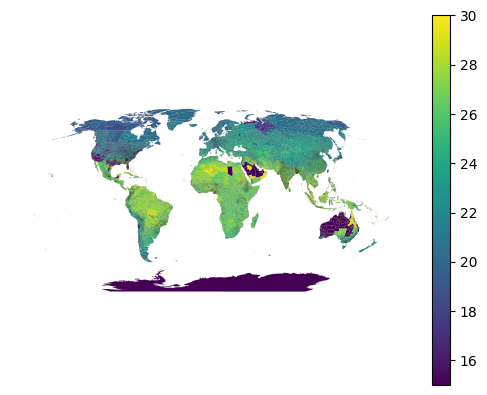

In [ ]:
mmt_df = _polygons.merge(mmt_df.reset_index(), on="region").to_crs("ESRI:54030")
fig, ax = plt.subplots()
mmt_df = mmt_df.to_crs("ESRI:54030")
mmt_df.plot(
    column="mmt",
    legend=True,
    edgecolor='black',
    linewidth=0.03,
    vmin = 15,
    vmax = 30,
    ax=ax,
)
ax.set_axis_off()
fig.savefig('mmt_65plus.png')

In [ ]:
_country_regions = _polygons[_polygons['ISO'] == iso_filter].index
ref_vals = betas_mmt['mmt'].sel(region=_country_regions.values)



ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()